In [13]:
from os import environ
environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from os.path import exists
from typing import List, Any, Dict, Union, Tuple

import sklearn
from sklearn.base import ClassifierMixin
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, Binarizer
from sklearn.pipeline import make_pipeline, Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingRegressor

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow import keras
from keras import layers

In [2]:
targ_dtype=np.int8

def check_arrs(preds: np.ndarray, targs: np.ndarray):
    """Checks that the lengths of the predictions and targets are compatible."""
    if preds.shape[0] != targs.shape[0]:
        raise ValueError(
            f'Shape of preds must equal that of targs but {preds.shape[0]} != {targs.shape[0]}'
        )
    if preds.dtype != targ_dtype or targs.dtype != targ_dtype:
        raise ValueError(
            f'Dtypes should be {targ_dtype} but preds is {preds.dtype} and targs is {targs.dtype}'
        )

    def check_range(arr: np.ndarray):
        if np.min(arr) < 0 or np.max(arr) > 1:
            raise ValueError(
                f'Incorrect range for the predictions: [{np.min(arr)}, {np.max(arr)}]'
            )
    
    check_range(preds)
    check_range(targs)



In [3]:
def accuracy(X: np.ndarray, Y: np.ndarray) -> float:
    """Returns the percentage of correct classifications."""
    check_arrs(X, Y)
    return np.mean(X == Y)

def prec_recall(preds: np.ndarray, targs: np.ndarray) -> Tuple[float, float]:
    """Returns the precision and recall of the predictions. Note that the arg order matters."""
    check_arrs(preds, targs)
    grid = np.zeros((2, 2), dtype=int)
    
    for i in range(preds.shape[0]):
        grid[preds[i], targs[i]] += 1
    
    d1 = grid[1, 1] + grid[1, 0]
    d2 = grid[1, 1] + grid[0, 1]
    return (
        grid[1, 1] / d1 if d1 != 0 else 0,
        grid[1, 1] / d2 if d2 != 0 else 0
    )

def f1_score(preds: np.ndarray, targs: np.ndarray) -> float:
    """Returns the f1 score of the predictions."""
    p, r = prec_recall(preds, targs)
    return 2 * p * r / (p + r)

In [4]:
def read_sheet(path: str) -> np.ndarray:
    """Reads the spreadsheet and converts to a numpy array."""
    return pd.read_csv(path).to_numpy()

def to_binary(arr: np.ndarray, threshold=0.5) -> np.ndarray:
    """Rounds all the values to be either 0 or 1."""
    processor = Binarizer(threshold=threshold)
    transformed = processor.fit_transform(arr.reshape((arr.shape[0], 1)))
    return transformed.flatten().astype(targ_dtype)

def feats_targs(root: str) -> Tuple[np.ndarray, np.ndarray]:
    """Returns the features and targets in the given folder."""
    return (
        read_sheet(root + 'feats.ignore.csv'), 
        to_binary(read_sheet(root + 'targs.ignore.csv').flatten(), threshold=0)
    )

train_feats, train_targs = feats_targs("../../../src/ml/data/train/")
valid_feats, valid_targs = feats_targs("../../../src/ml/data/valid/")

In [16]:
def get_path(model_name: str) -> str:
    """Returns the path of the plot given the model name."""
    return f'plots/classifiers/{model_name}.png'

def plot_preds(preds: np.ndarray, targs: np.ndarray, name: str):
    """Plots the predictions."""
    check_arrs(preds, targs)
    counts = np.zeros(np.max(targs) + 1)
    totals = np.zeros(counts.shape)
    for i in range(preds.shape[0]):
        counts[targs[i]] += preds[i] == targs[i]
        totals += targs[i]
    counts /= totals

    score = accuracy(preds, targs)
    p, r = prec_recall(preds, targs)
    
    f = plt.figure()
    ax = f.add_subplot(111)

    plt.clf()
    plt.title('Proportions of correct predictions')
    plt.xlabel('Actual outcome')
    plt.ylabel('Proportion of correct outcome predicted')

    plt.bar(
        np.arange(counts.shape[0]),
        counts,
        tick_label=list(map(str, np.arange(counts.shape[0])))
    )

    _, ymax = plt.ylim()
    plt.ylim(top = ymax * 1.3)
    plt.text(
        0.5, 
        0.9, 
        'accuracy = {:.6f}, precision = {:.6f}, recall = {:.6f}'.format(score, p, r), 
        ha = 'center', 
        va = 'center',
        transform = ax.transAxes
    )

    plt.savefig(get_path(name))

def test_model(
    model: ClassifierMixin,
    name: str,
    grid: Union[List[Dict[str, List[Any]]], Dict[str, List[Any]], None]=None,
    force: bool=True,
    degree=1,
):
    """Trains the model and plots its predictions."""
    path = get_path(name)
    if exists(path) and not force:
        print('Skipping plotting...')
        return

    if grid is None:
        clf = model
    else:
        clf = GridSearchCV(
            model,
            grid,
            n_jobs=8
        )

    clf = make_pipeline(
        PolynomialFeatures(degree=degree),
        StandardScaler(),
        clf
    )
    clf.fit(train_feats, train_targs)
    preds = clf.predict(valid_feats)
    plot_preds(
        to_binary(clf.predict(valid_feats)), 
        valid_targs,
        name
    )

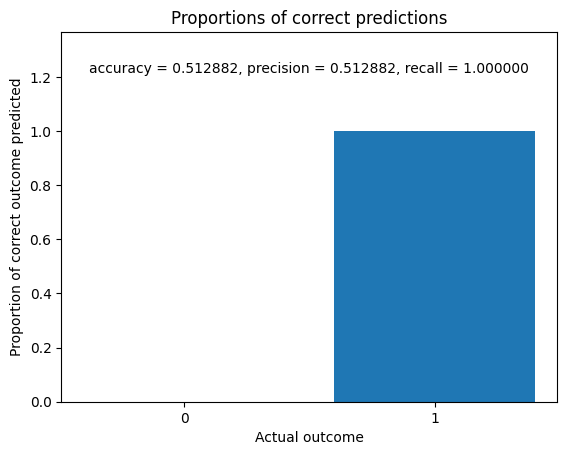

In [6]:
class Baseline(ClassifierMixin):
    def fit(self, X=None, Y=None):
        self.mean = np.mean(Y)

    def predict(self, X=None):
        return np.full(X.shape[0], self.mean)

baseline = Baseline()
test_model(
    baseline,
    'baseline'
)

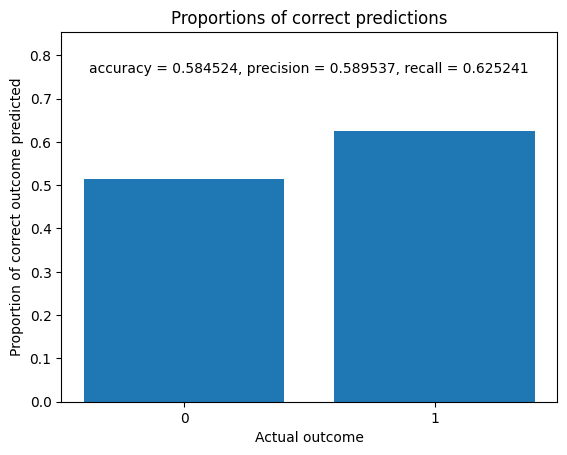

In [7]:
lin_reg = LinearRegression(

)

test_model(
    lin_reg,
    'linear_regression'
)

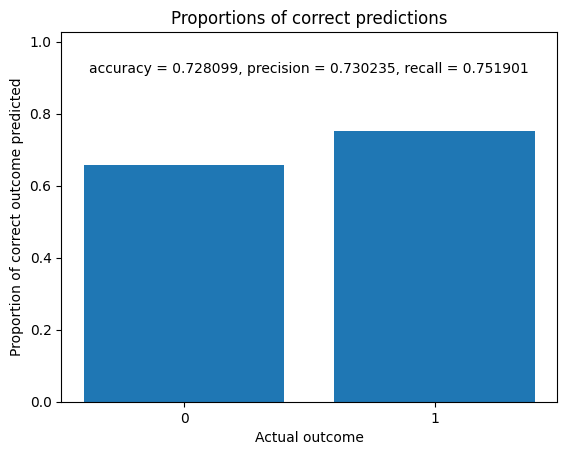

In [65]:
poly_reg = LinearRegression(
    fit_intercept=False
)

test_model(
    poly_reg,
    'polynomial_regression',
    degree=2
)

[0.56849325 0.3502565  0.57056348 0.64462355 0.2975383  0.61703957
 0.59756973 0.53019935 0.59756973 0.53019935 0.2671701  0.38368464
 0.2671701  0.58372986 0.59464579 0.57705281 0.3502565  0.63618291
 0.53019935 0.57705281]


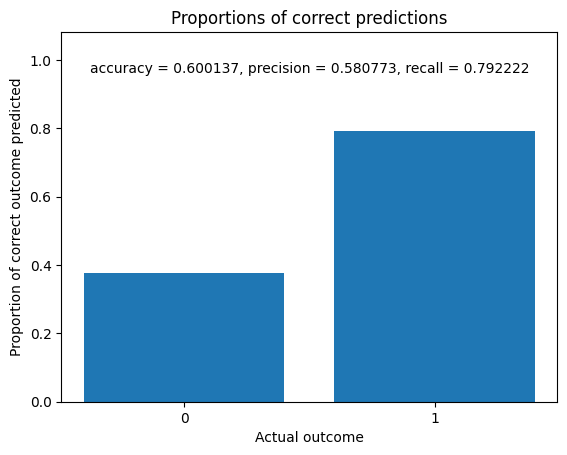

In [17]:
bagging = BaggingRegressor(
    LinearRegression(fit_intercept=False),
    n_jobs=8
)

test_model(
    bagging,
    'bagging_polynomial_regression',
    degree=2
)

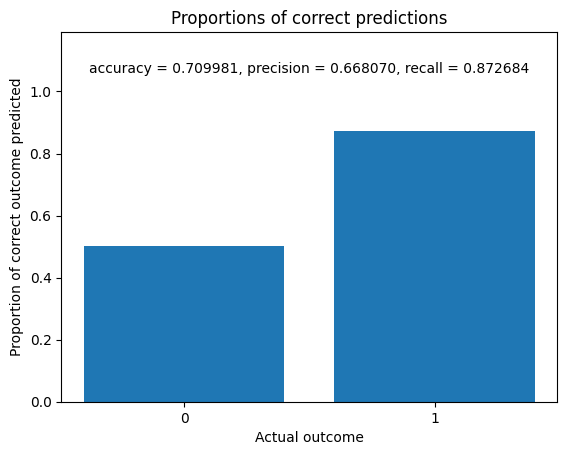

In [66]:
ridge = RidgeClassifier(

)

test_model(
    ridge,
    'ridge',
    grid={'alpha': [0.75, 1, 1.25]}
)

In [67]:
def test_knn(algorithm: str):
    """Tests a knn model with the correct grid search."""
    knn = KNeighborsClassifier(
        algorithm=algorithm,
        n_jobs=8
    )

    test_model(
        knn,
        algorithm,
        grid=[
            {'n_neighbors': [50], 'leaf_size': [50]},
            {'n_neighbors': [100], 'leaf_size': [100]}
        ]
    )

# test_knn('ball_tree')

In [68]:
# test_knn('kd_tree')

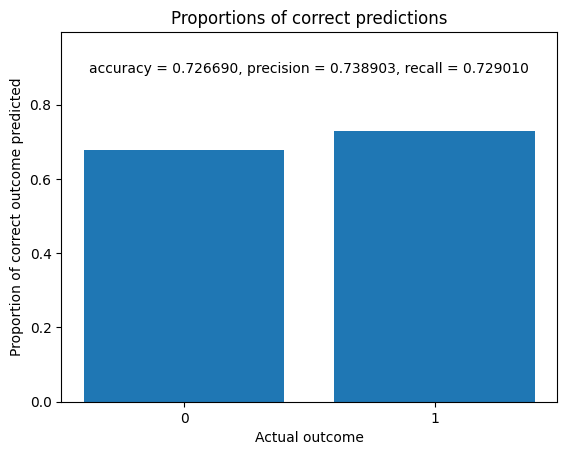

In [69]:
tree = DecisionTreeClassifier(

)

test_model(
    tree,
    'decision_tree',
    grid={'max_depth': [5, 10, 15], 'min_samples_leaf': [50, 100, 200]}
)

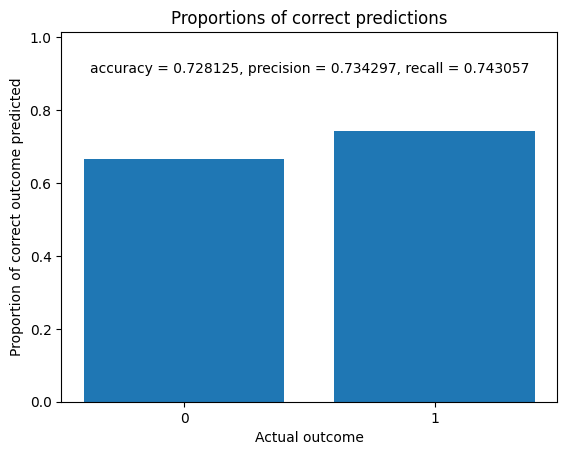

In [70]:
forest = RandomForestClassifier(
    n_jobs=8
)

test_model(
    forest,
    'random_forest',
    grid={'n_estimators': [30, 50, 100], 'min_samples_leaf': [50, 100, 200]}
)

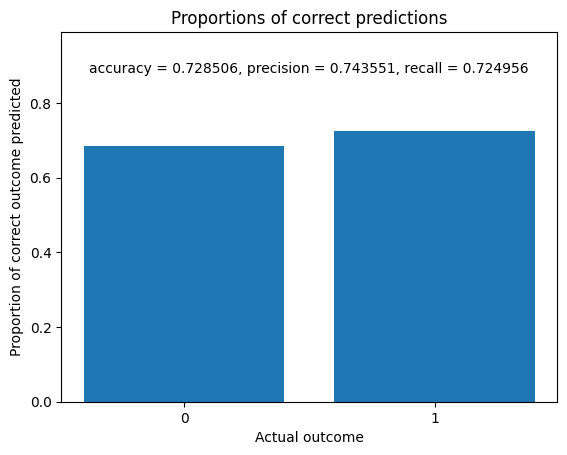

In [71]:
boost = XGBClassifier(
    n_jobs=8
)

test_model(
    boost,
    'xgboost',
    grid={'n_estimators': [5, 10, 15], 'max_depth': [4, 6, 8]}
)

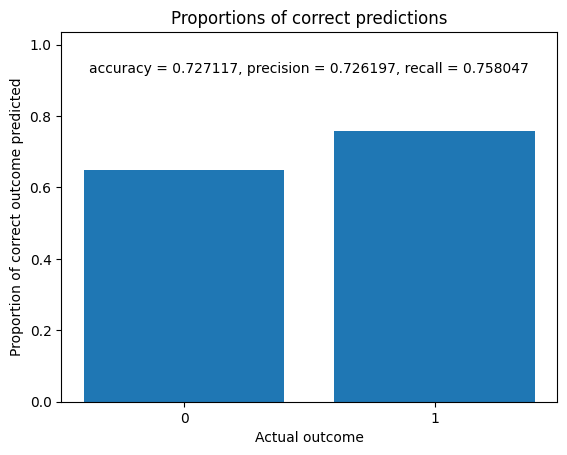

In [75]:
net = keras.Sequential(
    [
        layers.Dense(
            train_feats.shape[1] + 1, 
            input_shape=(train_feats.shape[1] + 1,), 
            activation='tanh'
        ),
        layers.Dense(1024, activation='tanh'),
        layers.Dense(1, activation='sigmoid')
    ]
)
net.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.MeanAbsoluteError()]
)

poly = PolynomialFeatures(degree=1)
scaler = StandardScaler()

net_pipe = Pipeline([
    ('polynomial', poly),
    ('scaler', scaler),
    ('net', net)
])

net_pipe.fit(
    train_feats, 
    train_targs,
    net__verbose=0,
    net__epochs=2,
    net__batch_size=32,
    net__use_multiprocessing=True,
    net__validation_data=(
        scaler.fit_transform(poly.fit_transform(valid_feats)), valid_targs
    )
)

net_preds = net_pipe.predict(
    valid_feats,
    verbose=0,
    use_multiprocessing=True
)

plot_preds(
    to_binary(net_pipe.predict(
        valid_feats,
        verbose=0,
        use_multiprocessing=True
    )),
    valid_targs, 
    'neural_net'
)